# Model Training

## Notebook Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import gc
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from wtfd.models.splitter import WindFarmSplitter
from wtfd.models.trainer import WindFaultTrainer

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

## Path Setup

In [3]:
project_root = Path(os.getcwd()).parent
RAW_DATA_ROOT = project_root / "data" / "raw" / "zenodo_windfarm_data"
PROCESSED_DATA_DIR = project_root / "data" / "processed"
CONFIG_PATH = project_root / "config" / "feature_map.yaml"

## Load Data

In [4]:
# 1. Load Data
df = pd.read_parquet(PROCESSED_DATA_DIR / 'master_dataset.parquet')
metadata_cols = ['time_stamp', 'asset_id', 'farm_id', 'target']
features = [col for col in df.columns if col not in metadata_cols]

## Split Data

In [5]:
# 2. HOLDOUT SPLIT: Set aside 20% of turbines as the final test
splitter = WindFarmSplitter(n_splits=5, random_state=42)
dev_df, holdout_df = splitter.get_train_test_split(df, test_size=0.2)

print(f"Development Set: {dev_df['asset_id'].nunique()} turbines")
print(f"Final Holdout: {holdout_df['asset_id'].nunique()} turbines")

Development Set: 24 turbines
Final Holdout: 8 turbines


## Train Models

In [6]:
model_types = ['logistic', 'rf', 'xgboost']
cv_summary = []

for m_type in model_types:
    print(f"\nEvaluating {m_type.upper()} via 5-Fold GroupCV...")
    fold_metrics = []
    
    # get_cv_iter ensures turbines are never split across folds
    # cv_iterator = splitter.get_cv_iter(dev_df)
    # for train_idx, val_idx in cv_iterator:
    
    # cv_iterator = splitter.get_cv_iter(dev_df)
    # for fold, (train_idx, val_idx) in enumerate(tqdm(cv_iterator, desc=f"CV Folds ({m_type})", leave=False)):
        
    cv_list = list(splitter.get_cv_iter(dev_df))
    for fold, (train_idx, val_idx) in enumerate(tqdm(cv_list, desc=f"CV Folds ({m_type})", leave=False)):
    
        train_slice = dev_df.iloc[train_idx]
        val_slice = dev_df.iloc[val_idx]
        
        # Prepare X, y
        X_train, y_train = train_slice[features], train_slice['target']
        X_val, y_val = val_slice[features], val_slice['target']
        
        # Handle scaling for Logistic
        if m_type == 'logistic':
            X_train = splitter.scaler.fit_transform(X_train)
            X_val = splitter.scaler.transform(X_val)
            
        trainer = WindFaultTrainer(model_type=m_type, random_state=42)
        trainer.train(X_train, y_train)

        # --- ADD DIAGNOSTICS HERE ---
        num_failures = y_train.sum()
        if num_failures == 0:
            print(f"  Warning: Fold {fold+1} has ZERO failure events in training set!")
            
        probs = trainer.model.predict_proba(X_val)[:, 1]
        print(f"  [Diagnostics - Fold {fold+1}]")
        print(f"  Max Prob: {probs.max():.4f} | Mean Prob: {probs.mean():.4f}")
        print(f"  Samples above 0.5 threshold: {(probs > 0.5).sum()}")
        # ----------------------------
        
        m = trainer.evaluate(X_val, y_val)
        fold_metrics.append(m['f1']) # Using F1-Score as the tournament metric
        print(f"  Fold {fold+1} F1: {m['f1']:.4f}")

        # Delete heavy objects and trigger GC
        del X_train, y_train, X_val, y_val, trainer
        gc.collect()
        
    cv_summary.append({
        'model': m_type,
        'cv_f1_mean': np.mean(fold_metrics),
        'cv_f1_std': np.std(fold_metrics)
    })

results_df = pd.DataFrame(cv_summary).set_index('model')
print("\n--- Tournament Standings (CV Results) ---")
display(results_df)


Evaluating LOGISTIC via 5-Fold GroupCV...


CV Folds (logistic):   0%|          | 0/5 [00:00<?, ?it/s]

  [Diagnostics - Fold 1]
  Max Prob: 0.8527 | Mean Prob: 0.4207
  Samples above 0.5 threshold: 205398
  Fold 1 F1: 0.0616
  [Diagnostics - Fold 2]
  Max Prob: 0.8868 | Mean Prob: 0.4809
  Samples above 0.5 threshold: 377117
  Fold 2 F1: 0.0216
  [Diagnostics - Fold 3]
  Max Prob: 0.8949 | Mean Prob: 0.4358
  Samples above 0.5 threshold: 300012
  Fold 3 F1: 0.0537
  [Diagnostics - Fold 4]
  Max Prob: 1.0000 | Mean Prob: 0.3993
  Samples above 0.5 threshold: 191536
  Fold 4 F1: 0.0249
  [Diagnostics - Fold 5]
  Max Prob: 1.0000 | Mean Prob: 0.5048
  Samples above 0.5 threshold: 437826
  Fold 5 F1: 0.0520

Evaluating RF via 5-Fold GroupCV...


CV Folds (rf):   0%|          | 0/5 [00:00<?, ?it/s]

  [Diagnostics - Fold 1]
  Max Prob: 0.7288 | Mean Prob: 0.0084
  Samples above 0.5 threshold: 174
  Fold 1 F1: 0.0000
  [Diagnostics - Fold 2]
  Max Prob: 0.9600 | Mean Prob: 0.0161
  Samples above 0.5 threshold: 1209
  Fold 2 F1: 0.0000
  [Diagnostics - Fold 3]
  Max Prob: 0.8100 | Mean Prob: 0.0113
  Samples above 0.5 threshold: 83
  Fold 3 F1: 0.0009
  [Diagnostics - Fold 4]
  Max Prob: 0.8295 | Mean Prob: 0.0167
  Samples above 0.5 threshold: 246
  Fold 4 F1: 0.0034
  [Diagnostics - Fold 5]
  Max Prob: 0.9400 | Mean Prob: 0.0211
  Samples above 0.5 threshold: 765
  Fold 5 F1: 0.0011

Evaluating XGBOOST via 5-Fold GroupCV...


CV Folds (xgboost):   0%|          | 0/5 [00:00<?, ?it/s]

  [Diagnostics - Fold 1]
  Max Prob: 0.9596 | Mean Prob: 0.1363
  Samples above 0.5 threshold: 55527
  Fold 1 F1: 0.0309
  [Diagnostics - Fold 2]
  Max Prob: 0.9800 | Mean Prob: 0.1936
  Samples above 0.5 threshold: 105239
  Fold 2 F1: 0.0236
  [Diagnostics - Fold 3]
  Max Prob: 0.9743 | Mean Prob: 0.1971
  Samples above 0.5 threshold: 117283
  Fold 3 F1: 0.0322
  [Diagnostics - Fold 4]
  Max Prob: 0.9865 | Mean Prob: 0.1414
  Samples above 0.5 threshold: 87394
  Fold 4 F1: 0.0547
  [Diagnostics - Fold 5]
  Max Prob: 0.9804 | Mean Prob: 0.2381
  Samples above 0.5 threshold: 191165
  Fold 5 F1: 0.0249

--- Tournament Standings (CV Results) ---


,cv_f1_mean,cv_f1_std
model,,
logistic,0.042760,0.016296
rf,0.001074,0.001230
xgboost,0.033245,0.011239


## Final Validation

In [7]:
# Identify winner from results_df
winner_type = results_df['cv_f1_mean'].idxmax()
print(f"The winning model is: {winner_type}")

# Final Train
final_trainer = WindFaultTrainer(model_type=winner_type)
X_dev, y_dev = dev_df[features], dev_df['target']
X_hold, y_hold = holdout_df[features], holdout_df['target']

if winner_type == 'logistic':
    X_dev = splitter.scaler.fit_transform(X_dev)
    X_hold = splitter.scaler.transform(X_hold)

final_trainer.train(X_dev, y_dev)

# Final Results
final_metrics = final_trainer.evaluate(X_hold, y_hold)
print("\n--- FINAL PERFORMANCE ON HOLDOUT TURBINES ---")
for k, v in final_metrics.items():
    if isinstance(v, float):
        print(f"{k.upper()}: {v:.4f}")

The winning model is: logistic

--- FINAL PERFORMANCE ON HOLDOUT TURBINES ---
PRECISION: 0.0405
RECALL: 0.7856
F1: 0.0770
ACCURACY: 0.5136
AUC: 0.7237


--- Threshold Tuning Results ---
Original F1 (at 0.50): 0.0770
Optimal Threshold:    0.7471
NEW Best F1 Score:     0.2104
Precision at Best:    0.2349
Recall at Best:       0.1906


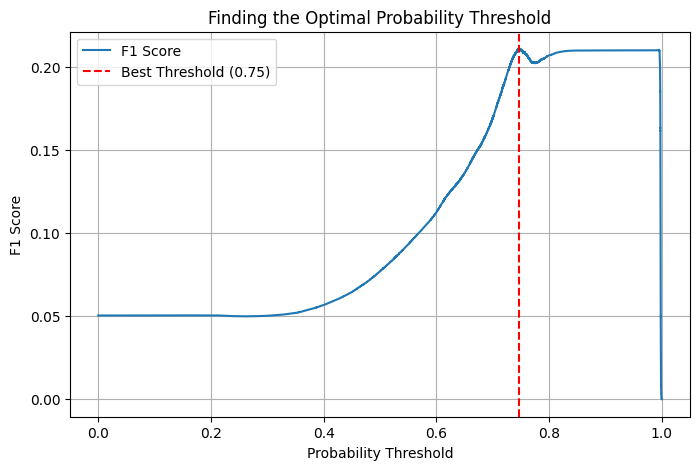

In [8]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

# 1. Get raw probabilities from the holdout set
probs = final_trainer.model.predict_proba(X_hold)[:, 1]

# 2. Calculate the Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_hold, probs)

# 3. Find the threshold that maximizes F1-Score
# (Adding a tiny epsilon 1e-10 to avoid division by zero)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"--- Threshold Tuning Results ---")
print(f"Original F1 (at 0.50): {final_metrics['f1']:.4f}")
print(f"Optimal Threshold:    {best_threshold:.4f}")
print(f"NEW Best F1 Score:     {f1_scores[best_idx]:.4f}")
print(f"Precision at Best:    {precision[best_idx]:.4f}")
print(f"Recall at Best:       {recall[best_idx]:.4f}")

# 4. Visualize the Trade-off
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.title('Finding the Optimal Probability Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

## Sandbox